# Smart Waste Detection and Segmentation

# Load Library

In [4]:
import numpy as np
import cv2 
import pandas as pd
from skimage import measure
import matplotlib.pyplot as plt
import os
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Hitung Distribusi kelas

Distribusi Kelas:
  cardboard: 403 gambar
  glass: 501 gambar
  metal: 410 gambar
  paper: 594 gambar
  plastic: 482 gambar
  trash: 137 gambar
  TOTAL: 2527 gambar


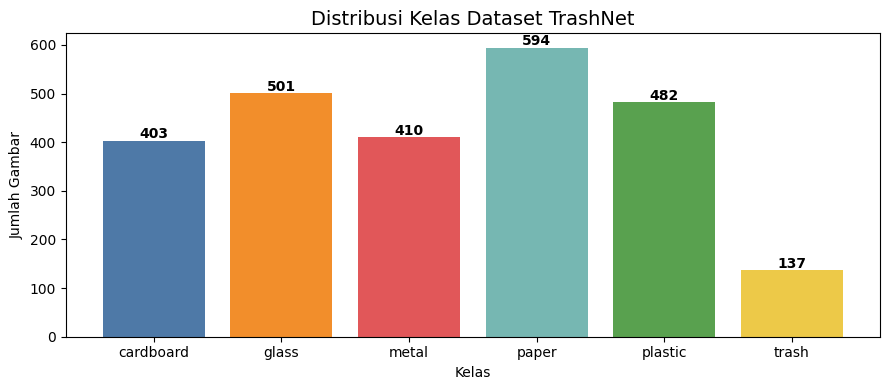

In [5]:
dataset_dir = 'dataset-resized'

class_count = Counter()
for class_name in os.listdir(dataset_dir):
    full_path = os.path.join(dataset_dir, class_name)
    if not os.path.isdir(full_path):
        continue
    count = len([f for f in os.listdir(full_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    class_count[class_name] = count

print('Distribusi Kelas:')
for k, v in class_count.items():
    print(f'  {k}: {v} gambar')
print(f'  TOTAL: {sum(class_count.values())} gambar')

plt.figure(figsize=(9, 4))
bars = plt.bar(class_count.keys(), class_count.values(),
               color=['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948'])
for bar, val in zip(bars, class_count.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontweight='bold')
    
plt.title('Distribusi Kelas Dataset TrashNet', fontsize=14)
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.tight_layout()
plt.show()

# Ambil Sample Gambar dari tiap kelas

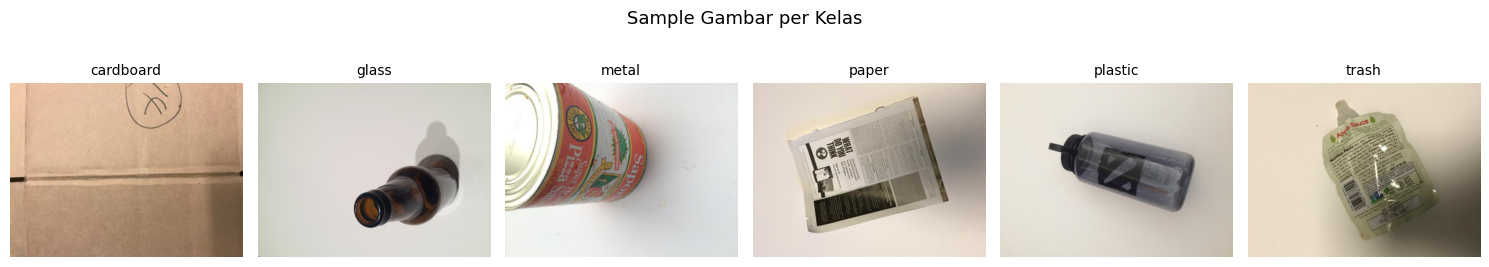

Gambar contoh: kelas=cardboard, shape=(384, 512, 3)


In [ ]:
dataset_dir = 'dataset-resized'
class_names = sorted([d for d in os.listdir(dataset_dir)
                      if os.path.isdir(os.path.join(dataset_dir, d))])

sample_images = {}
for class_name in class_names:
    class_dir = os.path.join(dataset_dir, class_name)
    files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if files:
        img_path = os.path.join(class_dir, files[0])
        sample_images[class_name] = cv2.imread(img_path)

fig, axes = plt.subplots(1, len(sample_images), figsize=(15, 3))
for ax, (cname, img) in zip(axes, sample_images.items()):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(cname, fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Gambar per Kelas', fontsize=13)
plt.tight_layout()
plt.show()


example_class   = class_names[0]
example_img_bgr = sample_images[example_class].copy()
img_bgr         = example_img_bgr
img_rgb         = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print(f'Gambar contoh: kelas={example_class}, shape={img_bgr.shape}')